<div style="text-align: right; font-weight: bold;">
東京工科大学コンピュータサイエンス学部<br>
福西広晃
</div>

----

# 感情分析の説明

- 感情分析とは、文章に含まれる**肯定的・否定的な感情や評価を自動的に判定するテキスト分析手法**である。

- 例えば、次のような文章を分析することができる。
  - 商品レビュー
  - 店舗の口コミ
  - SNSへの投稿
  - アンケートの自由記述

- 感情分析を行うことで、文章を書いた人が**どのような印象や評価を持っているか**を分析できる。

- 今回は、カフェの口コミデータに対して、**学習済みの自然言語処理モデル**を用いて感情分析を行う。

- 各口コミの文章をモデルに入力し、主に次のような感情に分類する。
  - **Positive**：肯定的な内容
  - **Negative**：否定的な内容

- 感情分析の結果について、次の内容を確認する。
  - Positive、Negativeと判定された**口コミの件数**
  - Positive、Negativeの**割合**
  - **星評価（1～5）と感情分析結果の関係**

- これにより、**数値として与えられた星評価と、口コミ文章から読み取れる感情との関係**を分析する。


----

# データの読み込み

**プロンプトの例**
「Google Driveの マイドライブ 内にある データ フォルダの中の テキスト フォルダに入っている 架空カフェ店口コミデータ.xlsx というExcelファイルを読み込んで、表示してください。」

# 感情分析の実行

**プロンプトの例**
「読み込んだ口コミデータに対して感情分析を実行してください」

# 感情分析結果の解析

**プロンプトの例**
「感情分析した口コミデータを分析して、結果がわかりやすくなるように集計やグラフを作成してください。」

----
----
----
----
----
----
----
----
----
----

# プログラム例

## データの読み込み

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os

# Excelファイルのパスを更新
#file_path = '/content/drive/MyDrive/東京成徳大学特別講義/2026年度/第02回/データ/テキスト/架空カフェ店口コミデータ.xlsx'
file_path = '/content/drive/MyDrive/tsu_2026_github/第02回/データ/テキスト/架空カフェ店口コミデータ.xlsx'

# ファイルが存在するか確認
if not os.path.exists(file_path):
    print(f"エラー: 指定されたパスにファイルが見つかりません。パスを確認してください: {file_path}")
    print("Googleドライブの「マイドライブ」からの正確なフォルダ階層とファイル名をご確認ください。")
    df = pd.DataFrame() # 空のDataFrameを作成して続行
else:
    # ExcelファイルをDataFrameに読み込む
    try:
        df = pd.read_excel(file_path)
        print("データを読み込みました。")
        display(df.head())
    except Exception as e:
        print(f"エラー: Excelファイルの読み込み中に問題が発生しました。エラー内容: {e}")
        print("Google Driveの接続が不安定な可能性があります。もう一度実行してみてください。")
        df = pd.DataFrame() # 空のDataFrameを作成して続行

データを読み込みました。


,ID,評価(1-5),口コミ
0,1,4,店内は落ち着いた雰囲気で、コーヒーもとても美味しかったです。良い時間を過ごせました。
1,2,2,混雑していて席がなかなか空きませんでした。あまりおすすめできません。
2,3,1,混雑していて席がなかなか空きませんでした。次は別のお店を利用するかもしれません。
3,4,4,スタッフの対応が丁寧で気持ちよく過ごせました。友人にもおすすめしたいです。
4,5,5,アクセスが良く、また来たいと思えるカフェでした。良い時間を過ごせました。


## 感情分析の実行

In [3]:
!pip install -q transformers
!pip install -q matplotlib_fontja

from transformers import pipeline
import torch

# GPUが利用可能ならGPUを使用
device = 0 if torch.cuda.is_available() else -1

# 感情分析モデルを読み込む
sentiment_analyzer = pipeline(
    "text-classification",
    model="tabularisai/multilingual-sentiment-analysis",
    device=device
)

print("感情分析モデルを読み込みました。")

# 口コミ列をリストに変換
reviews = df["口コミ"].fillna("").astype(str).tolist()

# すべての口コミを感情分析
results = sentiment_analyzer(
    reviews,
    truncation=True,
    batch_size=32
)

# 結果をDataFrameに追加
df["感情"] = [result["label"] for result in results]
df["感情スコア"] = [result["score"] for result in results]

display(df.head())

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

感情分析モデルを読み込みました。


,ID,評価(1-5),口コミ,感情,感情スコア
0,1,4,店内は落ち着いた雰囲気で、コーヒーもとても美味しかったです。良い時間を過ごせました。,Positive,0.854083
1,2,2,混雑していて席がなかなか空きませんでした。あまりおすすめできません。,Negative,0.582174
2,3,1,混雑していて席がなかなか空きませんでした。次は別のお店を利用するかもしれません。,Negative,0.630029
3,4,4,スタッフの対応が丁寧で気持ちよく過ごせました。友人にもおすすめしたいです。,Positive,0.906317
4,5,5,アクセスが良く、また来たいと思えるカフェでした。良い時間を過ごせました。,Positive,0.906057


## 感情分析結果の解析

### Positive / Negative の件数と割合

,件数,割合(%)
感情,,
Positive,70,70.0
Negative,25,25.0
Neutral,4,4.0
Very Negative,1,1.0


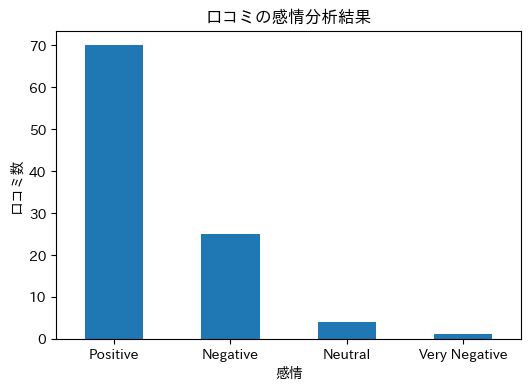

In [4]:
# 感情ごとの件数
sentiment_count = df["感情"].value_counts()

# 感情ごとの割合
sentiment_ratio = df["感情"].value_counts(normalize=True) * 100

# 表にまとめる
sentiment_summary = pd.DataFrame({
    "件数": sentiment_count,
    "割合(%)": sentiment_ratio.round(1)
})

display(sentiment_summary)


# 棒グラフ作成
import matplotlib.pyplot as plt
import matplotlib_fontja

sentiment_count.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("口コミの感情分析結果")
plt.xlabel("感情")
plt.ylabel("口コミ数")
plt.xticks(rotation=0)
plt.show()

### 星評価と感情分析結果を比較

感情,Negative,Neutral,Positive,Very Negative
評価(1-5),,,,
1,75.0,18.8,0.0,6.2
2,92.9,7.1,0.0,0.0
4,0.0,0.0,100.0,0.0
5,0.0,0.0,100.0,0.0


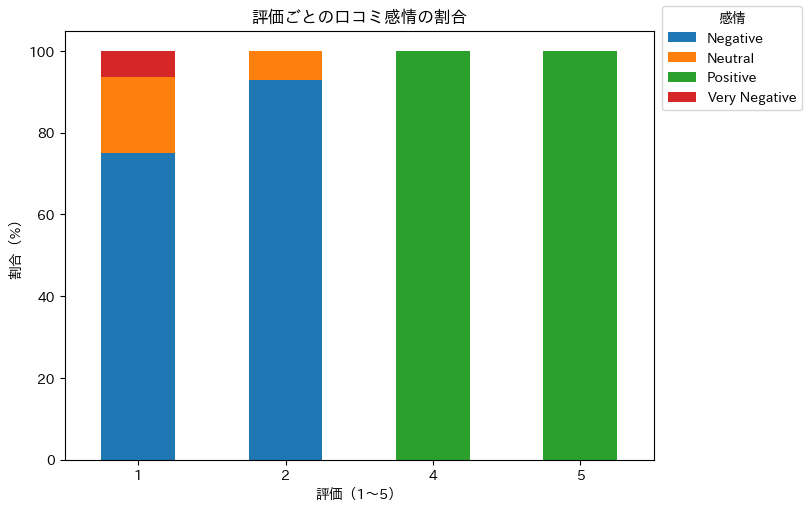

In [5]:
# 評価（1～5）ごとに、各感情が占める割合を計算
cross_ratio = pd.crosstab(
    df["評価(1-5)"],
    df["感情"],
    normalize="index"
) * 100

# 集計結果を小数第1位まで表示
display(cross_ratio.round(1))

# グラフを作成
fig, ax = plt.subplots(
    figsize=(8, 5),
    layout="constrained"
)

# 評価ごとの感情割合を積み上げ棒グラフで表示
cross_ratio.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    legend=False
)

# グラフのタイトルと軸ラベルを設定
ax.set_title("評価ごとの口コミ感情の割合")
ax.set_xlabel("評価（1～5）")
ax.set_ylabel("割合（%）")

# 横軸のラベルを横向きに表示
ax.tick_params(
    axis="x",
    rotation=0
)

# レジェンドをグラフの右外側に表示
fig.legend(
    title="感情",
    loc="outside right upper"
)

# グラフを表示
plt.show()